## Milestone 1: Data Foundation and Cleaning 

In [1]:
import pandas as pd

df = pd.read_csv("data/flights_sample.csv")

df.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,4,7,2,EV,4900,N759EV,FWA,DTW,1340,...,1423.0,-13.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,24,6,AS,611,N413AS,LAS,SEA,1910,...,2133.0,-12.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,7,8,3,WN,1483,N463WN,OAK,SEA,630,...,812.0,-8.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,5,26,2,WN,193,N7745A,STL,DAL,810,...,1222.0,152.0,0,0,NaN,0.0,0.0,0.0,152.0,0.0
4,2015,7,6,1,UA,253,N213UA,IAH,HNL,1000,...,1316.0,-2.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
import pandas as pd

df = pd.read_csv("data/flights_sample.csv")

df.shape

(581908, 31)

In [3]:
delay_columns = [
    "DEPARTURE_DELAY",
    "ARRIVAL_DELAY",
    "AIR_SYSTEM_DELAY",
    "SECURITY_DELAY",
    "AIRLINE_DELAY",
    "LATE_AIRCRAFT_DELAY",
    "WEATHER_DELAY"
]

df[delay_columns + ["CANCELLED", "CANCELLATION_REASON"]].isnull().sum()

DEPARTURE_DELAY          8640
ARRIVAL_DELAY           10553
AIR_SYSTEM_DELAY       475550
SECURITY_DELAY         475550
AIRLINE_DELAY          475550
LATE_AIRCRAFT_DELAY    475550
WEATHER_DELAY          475550
CANCELLED                   0
CANCELLATION_REASON    572856
dtype: int64

In [4]:
df["CANCELLED"].value_counts()

CANCELLED
0    572856
1      9052
Name: count, dtype: int64

In [5]:
cancelled_df = df[df["CANCELLED"] == 1]
active_df = df[df["CANCELLED"] == 0]

print("Cancelled flights:", cancelled_df.shape)
print("Active flights:", active_df.shape)

Cancelled flights: (9052, 31)
Active flights: (572856, 31)


In [6]:
active_df[delay_columns] = active_df[delay_columns].fillna(0)

active_df[delay_columns].isnull().sum()

DEPARTURE_DELAY        0
ARRIVAL_DELAY          0
AIR_SYSTEM_DELAY       0
SECURITY_DELAY         0
AIRLINE_DELAY          0
LATE_AIRCRAFT_DELAY    0
WEATHER_DELAY          0
dtype: int64

In [7]:
df["CANCELLATION_REASON"] = df["CANCELLATION_REASON"].fillna("Not Cancelled")

df["CANCELLATION_REASON"].value_counts()

CANCELLATION_REASON
Not Cancelled    572856
B                  4890
A                  2543
C                  1616
D                     3
Name: count, dtype: int64

In [8]:
cleaned_df = pd.concat([active_df, cancelled_df])

cleaned_df.shape

(581908, 31)

In [9]:
cleaned_df[delay_columns].isnull().sum()

DEPARTURE_DELAY        8640
ARRIVAL_DELAY          9052
AIR_SYSTEM_DELAY       9052
SECURITY_DELAY         9052
AIRLINE_DELAY          9052
LATE_AIRCRAFT_DELAY    9052
WEATHER_DELAY          9052
dtype: int64

In [10]:
cleaned_df["MONTH_NAME"] = pd.to_datetime(
    cleaned_df["MONTH"], format="%m"
).dt.month_name()

cleaned_df[["MONTH", "MONTH_NAME"]].head()

,MONTH,MONTH_NAME
0,4,April
1,1,January
2,7,July
3,5,May
4,7,July


In [11]:
day_map = {
    1: "Monday",
    2: "Tuesday",
    3: "Wednesday",
    4: "Thursday",
    5: "Friday",
    6: "Saturday",
    7: "Sunday"
}

cleaned_df["DAY_NAME"] = cleaned_df["DAY_OF_WEEK"].map(day_map)

cleaned_df[["DAY_OF_WEEK", "DAY_NAME"]].head()

,DAY_OF_WEEK,DAY_NAME
0,2,Tuesday
1,6,Saturday
2,3,Wednesday
3,2,Tuesday
4,1,Monday


In [12]:
cleaned_df["SCHEDULED_DEPARTURE"] = (
    cleaned_df["SCHEDULED_DEPARTURE"]
    .astype(str)
    .str.zfill(4)
)
cleaned_df["SCHEDULED_DEPARTURE"].head()

0    1340
1    1910
2    0630
3    0810
4    1000
Name: SCHEDULED_DEPARTURE, dtype: str

In [13]:
cleaned_df["DEPARTURE_HOUR"] = (
    cleaned_df["SCHEDULED_DEPARTURE"]
    .str[:2]
    .astype(int)
)

cleaned_df[["SCHEDULED_DEPARTURE", "DEPARTURE_HOUR"]].head()

,SCHEDULED_DEPARTURE,DEPARTURE_HOUR
0,1340,13
1,1910,19
2,0630,6
3,0810,8
4,1000,10


In [14]:
cleaned_df["ROUTE"] = (
    cleaned_df["ORIGIN_AIRPORT"]
    + "-"
    + cleaned_df["DESTINATION_AIRPORT"]
)

cleaned_df[["ORIGIN_AIRPORT", "DESTINATION_AIRPORT", "ROUTE"]].head()

,ORIGIN_AIRPORT,DESTINATION_AIRPORT,ROUTE
0,FWA,DTW,FWA-DTW
1,LAS,SEA,LAS-SEA
2,OAK,SEA,OAK-SEA
3,STL,DAL,STL-DAL
4,IAH,HNL,IAH-HNL


In [15]:
cleaned_df["FLIGHT_DATE"] = pd.to_datetime(
    cleaned_df[["YEAR", "MONTH", "DAY"]]
)

cleaned_df[["YEAR", "MONTH", "DAY", "FLIGHT_DATE"]].head()

,YEAR,MONTH,DAY,FLIGHT_DATE
0,2015,4,7,2015-04-07
1,2015,1,24,2015-01-24
2,2015,7,8,2015-07-08
3,2015,5,26,2015-05-26
4,2015,7,6,2015-07-06


In [16]:
cleaned_df["FLIGHT_DATE"].dtype

dtype('<M8[us]')

In [17]:
cleaned_df["DATE"] = cleaned_df["FLIGHT_DATE"].dt.isocalendar().week
cleaned_df["IS_WEEKEND"] = cleaned_df["DAY_NAME"].isin(["Saturday", "Sunday"])
cleaned_df[["DATE","DAY_NAME","IS_WEEKEND"]].head()

,DATE,DAY_NAME,IS_WEEKEND
0,15,Tuesday,False
1,4,Saturday,True
2,28,Wednesday,False
3,22,Tuesday,False
4,28,Monday,False


In [18]:
cleaned_df.columns

Index(['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER',
       'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
       'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT',
       'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE',
       'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME',
       'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON',
       'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
       'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY', 'MONTH_NAME', 'DAY_NAME',
       'DEPARTURE_HOUR', 'ROUTE', 'FLIGHT_DATE', 'DATE', 'IS_WEEKEND'],
      dtype='str')

In [19]:
cleaned_df.to_csv("data/flights_cleaned.csv", index=False)

print("Updated cleaned dataset saved successfully!")

Updated cleaned dataset saved successfully!


In [20]:
test_df = pd.read_csv("data/flights_cleaned.csv")
test_df.head()

C:\Users\Asus\AppData\Local\Temp\ipykernel_1488\479681572.py:1: DtypeWarning: Columns (0: CANCELLATION_REASON) have mixed types. Specify dtype option on import or set low_memory=False.
  test_df = pd.read_csv("data/flights_cleaned.csv")


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,MONTH_NAME,DAY_NAME,DEPARTURE_HOUR,ROUTE,FLIGHT_DATE,DATE,IS_WEEKEND
0,2015,4,7,2,EV,4900,N759EV,FWA,DTW,1340,...,0.0,0.0,0.0,April,Tuesday,13,FWA-DTW,2015-04-07,15,False
1,2015,1,24,6,AS,611,N413AS,LAS,SEA,1910,...,0.0,0.0,0.0,January,Saturday,19,LAS-SEA,2015-01-24,4,True
2,2015,7,8,3,WN,1483,N463WN,OAK,SEA,630,...,0.0,0.0,0.0,July,Wednesday,6,OAK-SEA,2015-07-08,28,False
3,2015,5,26,2,WN,193,N7745A,STL,DAL,810,...,0.0,152.0,0.0,May,Tuesday,8,STL-DAL,2015-05-26,22,False
4,2015,7,6,1,UA,253,N213UA,IAH,HNL,1000,...,0.0,0.0,0.0,July,Monday,10,IAH-HNL,2015-07-06,28,False


## Milestone 2: Visual Exploration and Delay Trends 

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/flights_cleaned.csv", low_memory=False)

df.shape

(581908, 38)

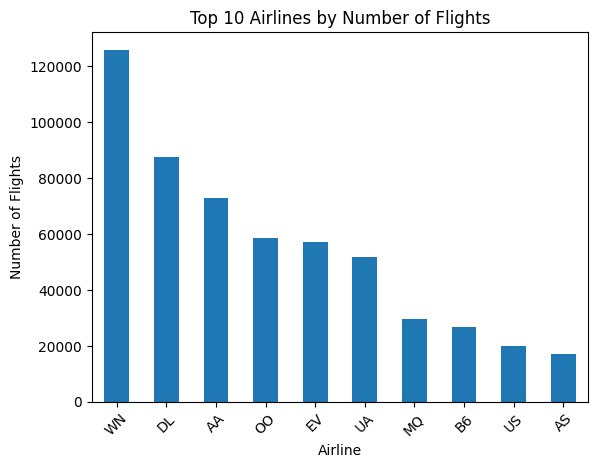

In [23]:
top_airlines = df["AIRLINE"].value_counts().head(10)

plt.figure()
top_airlines.plot(kind="bar")
plt.title("Top 10 Airlines by Number of Flights")
plt.xlabel("Airline")
plt.ylabel("Number of Flights")
plt.xticks(rotation=45)
plt.show()

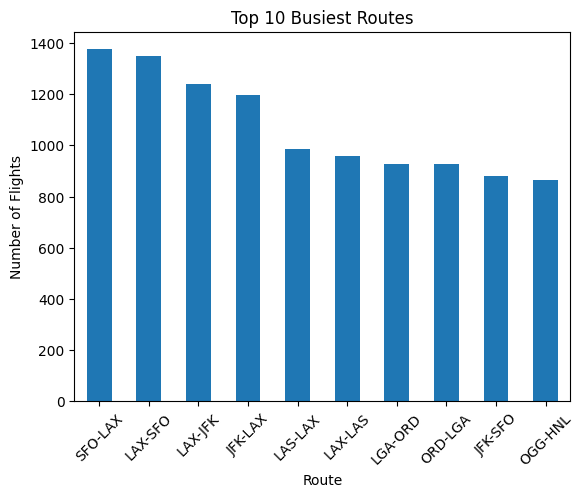

In [24]:
top_routes = df["ROUTE"].value_counts().head(10)

plt.figure()
top_routes.plot(kind="bar")
plt.title("Top 10 Busiest Routes")
plt.xlabel("Route")
plt.ylabel("Number of Flights")
plt.xticks(rotation=45)
plt.show()

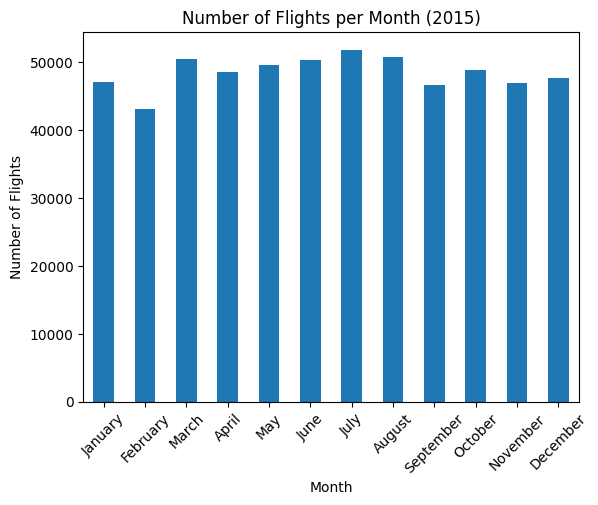

In [25]:
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_counts = df["MONTH_NAME"].value_counts().reindex(month_order)

plt.figure()
monthly_counts.plot(kind="bar")
#monthly_counts.plot(kind="line", marker="o")
plt.title("Number of Flights per Month (2015)")
plt.xlabel("Month")
plt.ylabel("Number of Flights")
plt.xticks(rotation=45)
plt.show()

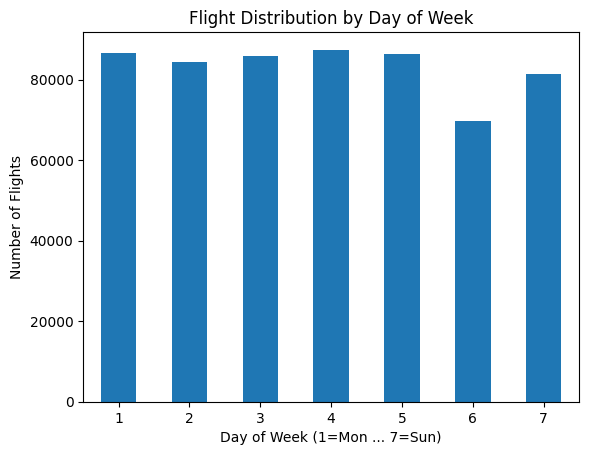

In [26]:
day_counts = df["DAY_OF_WEEK"].value_counts().sort_index()

plt.figure()
day_counts.plot(kind="bar")
#day_counts.plot(kind="line", marker="o")
plt.title("Flight Distribution by Day of Week")
plt.xlabel("Day of Week (1=Mon ... 7=Sun)")
plt.ylabel("Number of Flights")
plt.xticks(rotation=0)
plt.show()

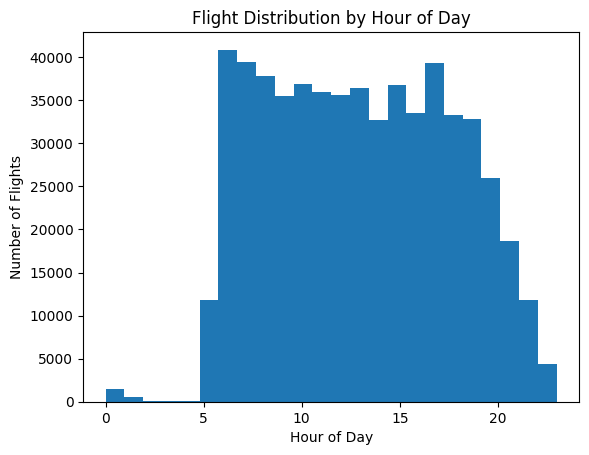

In [27]:
hour_counts = df["DEPARTURE_HOUR"].value_counts().sort_index()

plt.figure()
#hour_counts.plot(kind="bar")
plt.hist(df["DEPARTURE_HOUR"].dropna(), bins=24)
plt.title("Flight Distribution by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Flights")
plt.xticks(rotation=0)
plt.show()

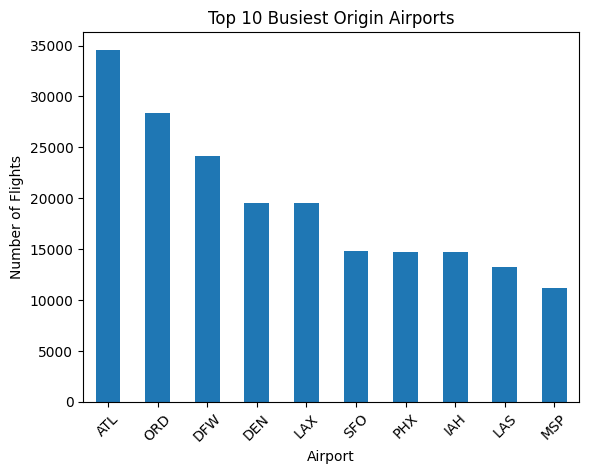

In [28]:
top_airports = df["ORIGIN_AIRPORT"].value_counts().head(10)

plt.figure()
top_airports.plot(kind="bar")
plt.title("Top 10 Busiest Origin Airports")
plt.xlabel("Airport")
plt.ylabel("Number of Flights")
plt.xticks(rotation=45)
plt.show()

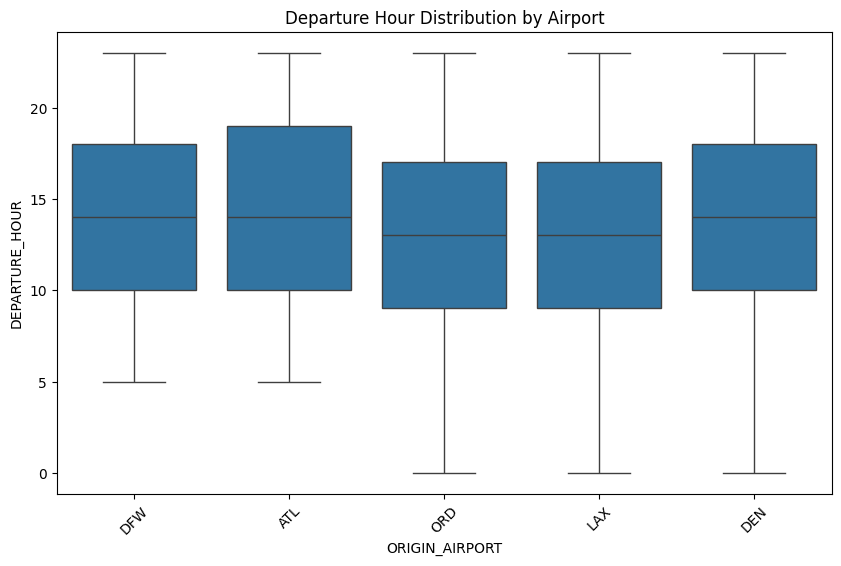

In [29]:
top_airports = df["ORIGIN_AIRPORT"].value_counts().head(5).index
airport_df = df[df["ORIGIN_AIRPORT"].isin(top_airports)]
plt.figure(figsize=(10,6))
sns.boxplot(x="ORIGIN_AIRPORT", y="DEPARTURE_HOUR", data=airport_df)
plt.title("Departure Hour Distribution by Airport")
plt.xticks(rotation=45)
plt.show()

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("data/flights_cleaned.csv", low_memory=False)

# Delay columns
delay_cols = [
    'AIRLINE_DELAY',
    'WEATHER_DELAY',
    'AIR_SYSTEM_DELAY',
    'SECURITY_DELAY',
    'LATE_AIRCRAFT_DELAY'
]

# Group by airline and calculate average delays
airline_delay = df.groupby("AIRLINE")[delay_cols].mean()

print(airline_delay.head())

         AIRLINE_DELAY  WEATHER_DELAY  AIR_SYSTEM_DELAY  SECURITY_DELAY  \
AIRLINE                                                                   
AA            4.021366       0.682314          2.403847        0.023805   
AS            1.965226       0.249578          1.757923        0.037390   
B6            3.970634       0.443499          3.884215        0.039663   
DL            3.199800       0.672580          2.087331        0.003016   
EV            4.026510       0.346904          3.105807        0.000000   

         LATE_AIRCRAFT_DELAY  
AIRLINE                       
AA                  4.000209  
AS                  2.169564  
B6                  5.802334  
DL                  2.420290  
EV                  4.740286  


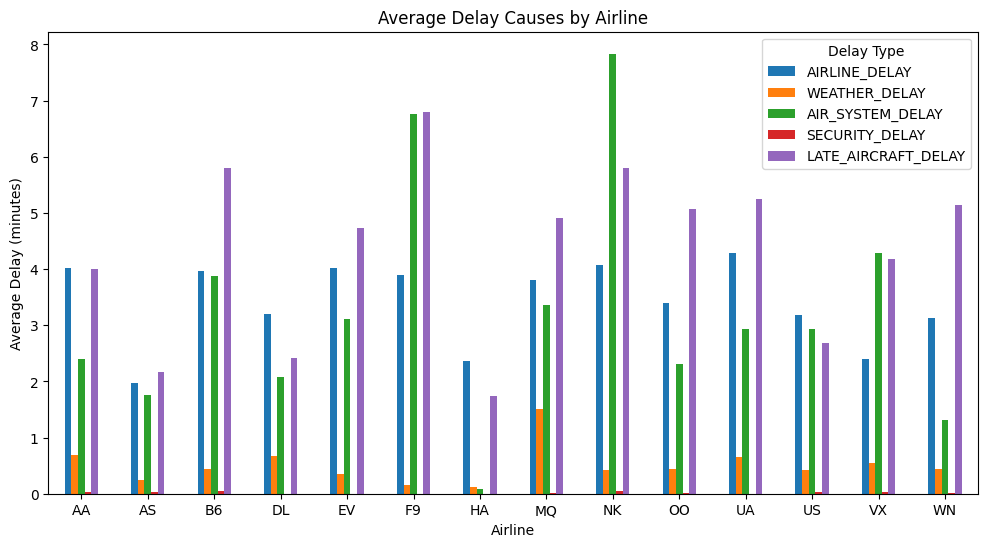

In [31]:
airline_delay.plot(kind='bar', figsize=(12,6))

plt.title("Average Delay Causes by Airline")
plt.xlabel("Airline")
plt.ylabel("Average Delay (minutes)")
plt.legend(title="Delay Type")
plt.xticks(rotation=0)
plt.show()

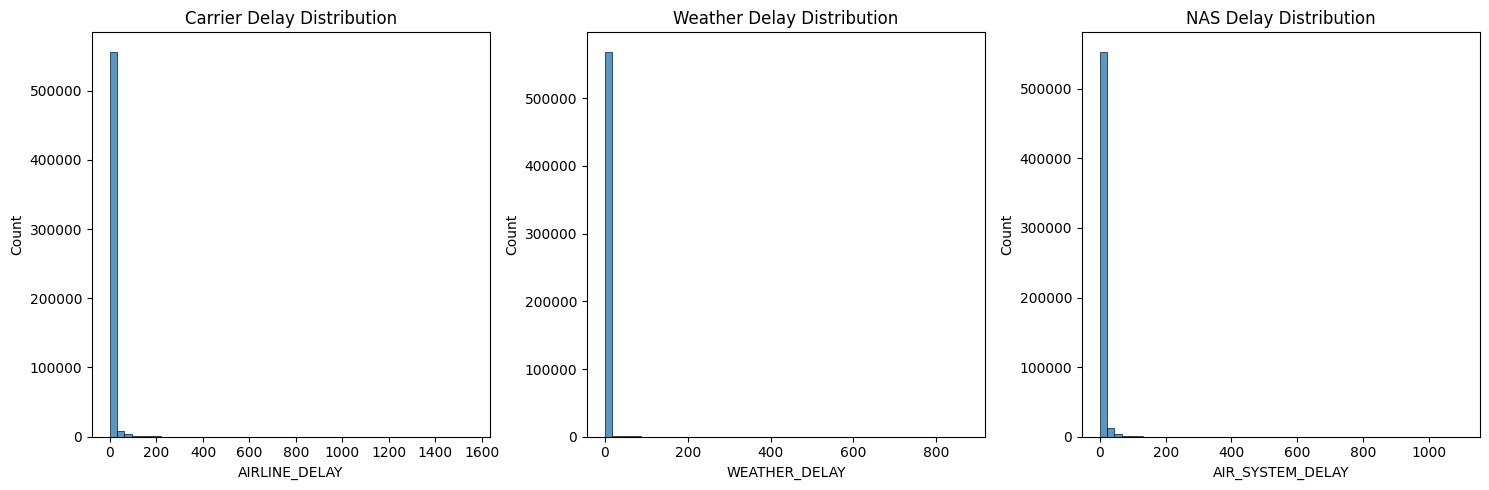

In [32]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.histplot(df['AIRLINE_DELAY'], bins=50)
plt.title("Carrier Delay Distribution")

plt.subplot(1,3,2)
sns.histplot(df['WEATHER_DELAY'], bins=50)
plt.title("Weather Delay Distribution")

plt.subplot(1,3,3)
sns.histplot(df['AIR_SYSTEM_DELAY'], bins=50)
plt.title("NAS Delay Distribution")

plt.tight_layout()
plt.show()

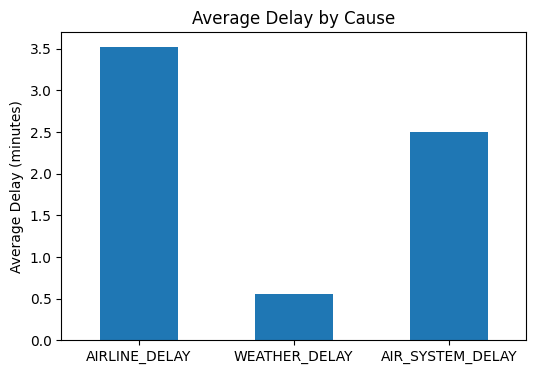

In [33]:
delay_means = df[['AIRLINE_DELAY','WEATHER_DELAY','AIR_SYSTEM_DELAY']].mean()

delay_means.plot(kind='bar', figsize=(6,4))

plt.title("Average Delay by Cause")
plt.xticks(rotation=0)
plt.ylabel("Average Delay (minutes)")
plt.show()

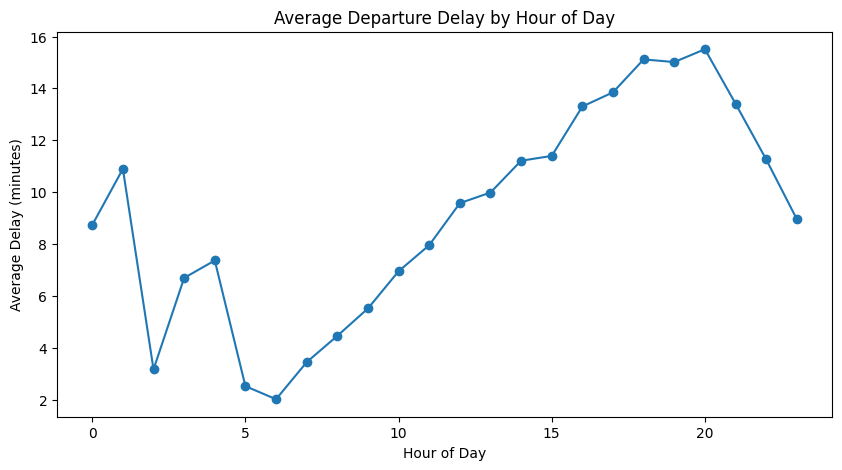

In [34]:
delay_by_hour = df.groupby("DEPARTURE_HOUR")["DEPARTURE_DELAY"].mean()

plt.figure(figsize=(10,5))
delay_by_hour.plot(kind="line", marker="o")

plt.title("Average Departure Delay by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Delay (minutes)")

plt.show()

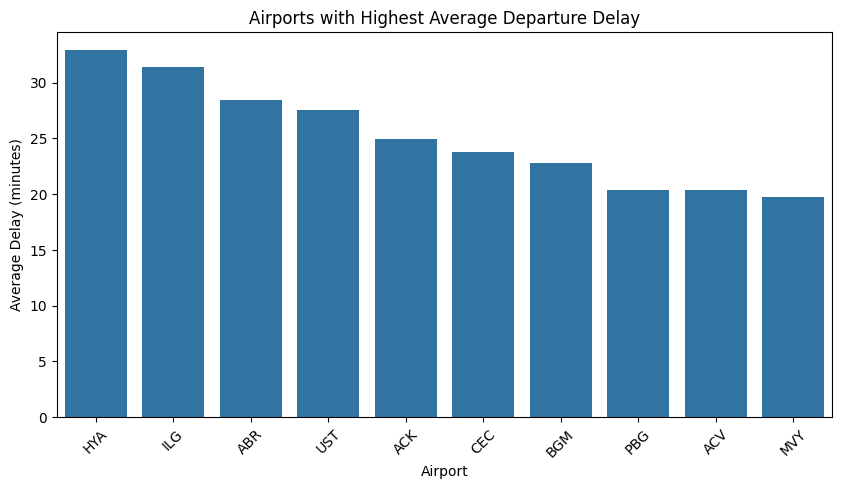

In [35]:
df_airports = df[df["ORIGIN_AIRPORT"].astype(str).str.isalpha()]

airport_delay = df_airports.groupby("ORIGIN_AIRPORT")["DEPARTURE_DELAY"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

sns.barplot(x=airport_delay.index, y=airport_delay.values)

plt.title("Airports with Highest Average Departure Delay")
plt.xlabel("Airport")
plt.ylabel("Average Delay (minutes)")
plt.xticks(rotation=45)

plt.show()

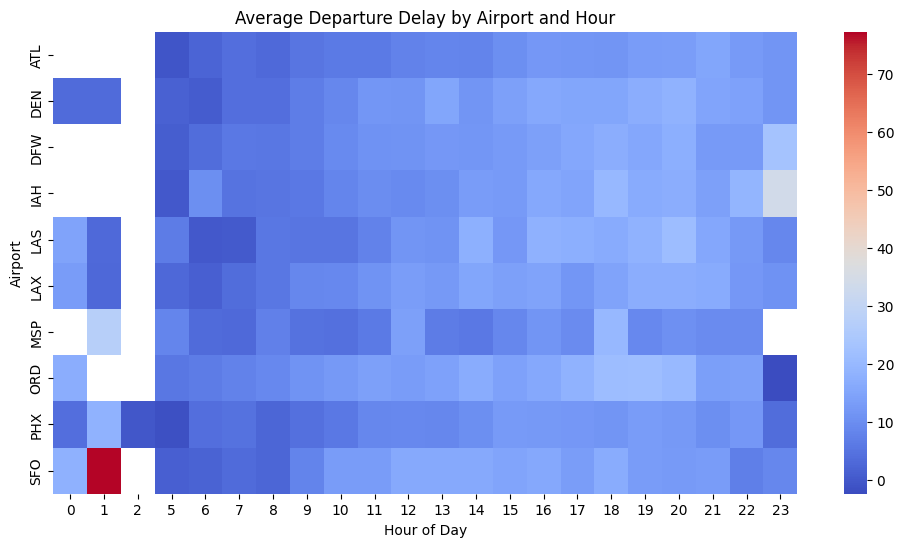

In [36]:
df_airports = df[df["ORIGIN_AIRPORT"].astype(str).str.isalpha()]
top_airports = df_airports["ORIGIN_AIRPORT"].value_counts().head(10).index
df_top = df_airports[df_airports["ORIGIN_AIRPORT"].isin(top_airports)]
delay_pivot = df_top.pivot_table(
    values="DEPARTURE_DELAY",
    index="ORIGIN_AIRPORT",
    columns="DEPARTURE_HOUR",
    aggfunc="mean"
)
plt.figure(figsize=(12,6))

sns.heatmap(delay_pivot, cmap="coolwarm", annot=False)

plt.title("Average Departure Delay by Airport and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Airport")

plt.show()

## Milestone 3: Route, Cancellation, and Seasonal Insights 

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("data/flights_cleaned.csv")
df.head()

C:\Users\Asus\AppData\Local\Temp\ipykernel_1488\3795264085.py:4: DtypeWarning: Columns (0: CANCELLATION_REASON) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/flights_cleaned.csv")


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,MONTH_NAME,DAY_NAME,DEPARTURE_HOUR,ROUTE,FLIGHT_DATE,DATE,IS_WEEKEND
0,2015,4,7,2,EV,4900,N759EV,FWA,DTW,1340,...,0.0,0.0,0.0,April,Tuesday,13,FWA-DTW,2015-04-07,15,False
1,2015,1,24,6,AS,611,N413AS,LAS,SEA,1910,...,0.0,0.0,0.0,January,Saturday,19,LAS-SEA,2015-01-24,4,True
2,2015,7,8,3,WN,1483,N463WN,OAK,SEA,630,...,0.0,0.0,0.0,July,Wednesday,6,OAK-SEA,2015-07-08,28,False
3,2015,5,26,2,WN,193,N7745A,STL,DAL,810,...,0.0,152.0,0.0,May,Tuesday,8,STL-DAL,2015-05-26,22,False
4,2015,7,6,1,UA,253,N213UA,IAH,HNL,1000,...,0.0,0.0,0.0,July,Monday,10,IAH-HNL,2015-07-06,28,False


In [38]:
top_routes = df["ROUTE"].value_counts().head(10)

print(top_routes)

ROUTE
SFO-LAX    1375
LAX-SFO    1347
LAX-JFK    1240
JFK-LAX    1197
LAS-LAX     985
LAX-LAS     959
LGA-ORD     928
ORD-LGA     926
JFK-SFO     881
OGG-HNL     865
Name: count, dtype: int64


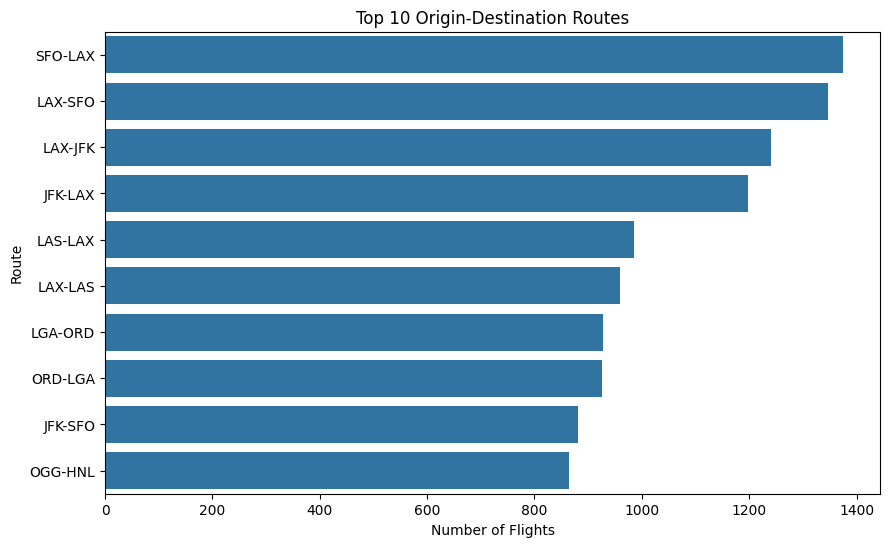

In [39]:
plt.figure(figsize=(10,6))

sns.barplot(x=top_routes.values, y=top_routes.index)

plt.title("Top 10 Origin-Destination Routes")
plt.xlabel("Number of Flights")
plt.ylabel("Route")

plt.show()

In [40]:
df_airports = df[df["ORIGIN_AIRPORT"].astype(str).str.isalpha()]
top_airports = df["ORIGIN_AIRPORT"].value_counts().head(10).index
df_top = df[df["ORIGIN_AIRPORT"].isin(top_airports)]
top_routes = df_top["ROUTE"].value_counts().head(15).index
df_top_routes = df_top[df_top["ROUTE"].isin(top_routes)]
delay_pivot = df_top_routes.pivot_table(
    values="DEPARTURE_DELAY",
    index="ORIGIN_AIRPORT",
    columns="DESTINATION_AIRPORT",
    aggfunc="mean"
)
delay_pivot = delay_pivot.fillna(0)
print(delay_pivot)

DESTINATION_AIRPORT        JFK        LAS        LAX        LGA      MCO  \
ORIGIN_AIRPORT                                                             
ATL                   0.000000   0.000000   0.000000  13.257073  9.92823   
DFW                   0.000000   0.000000   0.000000   0.000000  0.00000   
LAS                   0.000000   0.000000  10.996933   0.000000  0.00000   
LAX                  12.256702  10.575630   0.000000   0.000000  0.00000   
ORD                   0.000000   0.000000  14.019380  15.356659  0.00000   
SFO                  12.776840   9.340686  13.779192   0.000000  0.00000   

DESTINATION_AIRPORT        ORD        PHX       SEA        SFO  
ORIGIN_AIRPORT                                                  
ATL                   0.000000   0.000000  0.000000   0.000000  
DFW                  11.957219   0.000000  0.000000   0.000000  
LAS                   0.000000   0.000000  0.000000   0.000000  
LAX                  12.201456  12.175766  4.856226  15.045038  
O

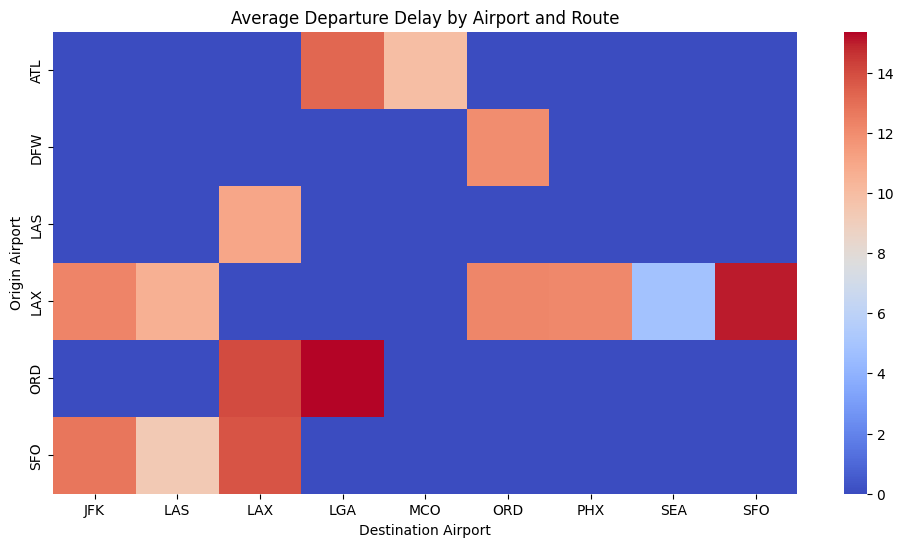

In [41]:
plt.figure(figsize=(12,6))

sns.heatmap(delay_pivot, cmap="coolwarm")

plt.title("Average Departure Delay by Airport and Route")
plt.xlabel("Destination Airport")
plt.ylabel("Origin Airport")

plt.show()

In [42]:
import pandas as pd
import plotly.express as px

airport_coords = {
    "ATL": [33.6407, -84.4277],
    "LAX": [33.9416, -118.4085],
    "JFK": [40.6413, -73.7781],
    "ORD": [41.9742, -87.9073],
    "DFW": [32.8998, -97.0403],
    "DEN": [39.8561, -104.6737],
    "SFO": [37.6213, -122.3790],
    "LAS": [36.0840, -115.1537],
    "SEA": [47.4502, -122.3088],
    "PHX": [33.4342, -112.0116]
}

# Top 10 busiest airports
airport_counts = df["ORIGIN_AIRPORT"].value_counts().head(10)

# Average delay
airport_delay = df.groupby("ORIGIN_AIRPORT")["DEPARTURE_DELAY"].mean()

# Create dataframe
airport_data = pd.DataFrame({
    "airport": airport_counts.index,
    "flights": airport_counts.values,
    "avg_delay": airport_delay[airport_counts.index].values
})

airport_data = airport_data[airport_data["airport"].isin(airport_coords.keys())]

airport_data["lat"] = airport_data["airport"].apply(lambda x: airport_coords[x][0])
airport_data["lon"] = airport_data["airport"].apply(lambda x: airport_coords[x][1])
# Create map
fig = px.scatter_geo(
    airport_data,
    lat="lat",
    lon="lon",
    size="flights",
    color="avg_delay",
    hover_name="airport",
    scope="usa",
    title="Busiest Airports and Average Delays"
)

fig.show()

In [43]:
import calendar
monthly_cancellations = df.groupby("MONTH")["CANCELLED"].sum()
monthly_cancellations = monthly_cancellations.reset_index()

monthly_cancellations["MONTH"] = monthly_cancellations["MONTH"].apply(lambda x: calendar.month_name[x])
fig = px.line(
    monthly_cancellations,
    x="MONTH",
    y="CANCELLED",
    markers=True,
    title="Monthly Flight Cancellation Trends"
)

fig.show()

In [44]:
cancelled_flights = df[df["CANCELLED"] == 1]
cancellation_counts = cancelled_flights["CANCELLATION_REASON"].value_counts()
reason_map = {
    "A": "Carrier",
    "B": "Weather",
    "C": "NAS",
    "D": "Security"
}

cancellation_counts.index = cancellation_counts.index.map(reason_map)
cancellation_counts = cancellation_counts.reset_index()
cancellation_counts.columns = ["Reason", "Count"]
print(cancellation_counts)

     Reason  Count
0   Weather   4890
1   Carrier   2543
2       NAS   1616
3  Security      3


In [45]:
import plotly.express as px

fig = px.pie(
    cancellation_counts,
    names="Reason",
    values="Count",
    title="Flight Cancellation Reasons"
)

fig.show()

In [46]:
# Average delay by month
monthly_delay = df.groupby('MONTH')['ARRIVAL_DELAY'].mean()

print(monthly_delay)

MONTH
1     5.688256
2     8.310048
3     4.724340
4     3.538466
5     4.552207
6     9.554415
7     6.786311
8     4.543492
9    -0.797162
10   -0.537215
11    0.904588
12    6.308776
Name: ARRIVAL_DELAY, dtype: float64


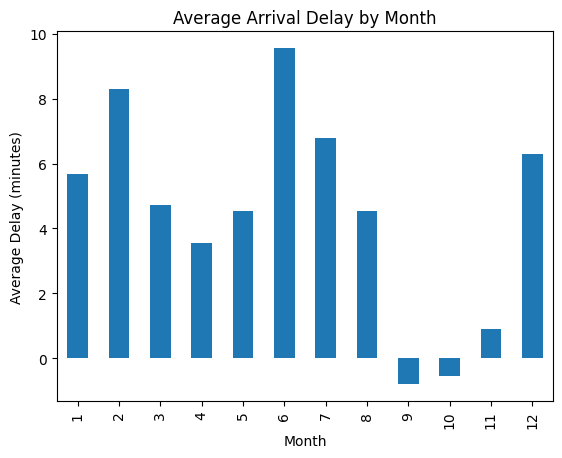

In [47]:
import matplotlib.pyplot as plt

monthly_delay.plot(kind='bar')
plt.title("Average Arrival Delay by Month")
plt.xlabel("Month")
plt.ylabel("Average Delay (minutes)")
plt.show()

In [48]:
winter = df[df['MONTH'].isin([12,1,2])]

winter_delay = winter['ARRIVAL_DELAY'].mean()

print("Average Winter Delay:", winter_delay)

Average Winter Delay: 6.709740167436014


In [49]:
overall_delay = df['ARRIVAL_DELAY'].mean()

print("Overall Average Delay:", overall_delay)

Overall Average Delay: 4.454959012387057


In [50]:
winter_cancel = df[df['MONTH'].isin([12,1,2])]['CANCELLED'].mean()

print("Winter Cancellation Rate:", winter_cancel)
winter_cancel_percentage=round(winter_cancel*100,2)
print("Cancelled flights in winter",winter_cancel_percentage,"%")

Winter Cancellation Rate: 0.029993613747859155
Cancelled flights in winter 3.0 %


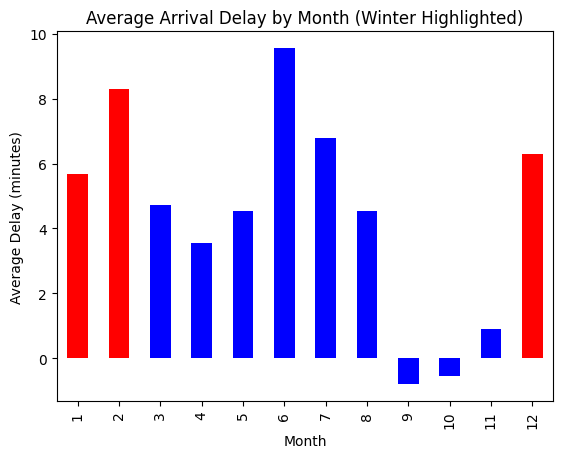

In [51]:
winter_months = [12,1,2]

colors = ['red' if m in winter_months else 'blue' for m in monthly_delay.index]

monthly_delay.plot(kind='bar', color=colors)

plt.title("Average Arrival Delay by Month (Winter Highlighted)")
plt.xlabel("Month")
plt.ylabel("Average Delay (minutes)")

plt.show()

## Milestone 4: Report and Presentation

In [52]:
print("AirFly Insights Final Analysis Loaded Successfully!")

AirFly Insights Final Analysis Loaded Successfully!


In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
df = pd.read_csv("data/flights_cleaned.csv", low_memory=False)

df.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,MONTH_NAME,DAY_NAME,DEPARTURE_HOUR,ROUTE,FLIGHT_DATE,DATE,IS_WEEKEND
0,2015,4,7,2,EV,4900,N759EV,FWA,DTW,1340,...,0.0,0.0,0.0,April,Tuesday,13,FWA-DTW,2015-04-07,15,False
1,2015,1,24,6,AS,611,N413AS,LAS,SEA,1910,...,0.0,0.0,0.0,January,Saturday,19,LAS-SEA,2015-01-24,4,True
2,2015,7,8,3,WN,1483,N463WN,OAK,SEA,630,...,0.0,0.0,0.0,July,Wednesday,6,OAK-SEA,2015-07-08,28,False
3,2015,5,26,2,WN,193,N7745A,STL,DAL,810,...,0.0,152.0,0.0,May,Tuesday,8,STL-DAL,2015-05-26,22,False
4,2015,7,6,1,UA,253,N213UA,IAH,HNL,1000,...,0.0,0.0,0.0,July,Monday,10,IAH-HNL,2015-07-06,28,False


## 1. Overview of Flight Data
This section provides a general understanding of the flight dataset. 
It shows how flight activity is distributed across different months.

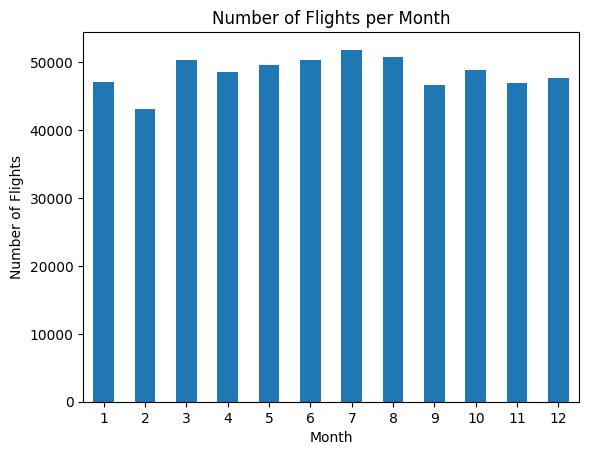

In [54]:
# Flights per month
monthly_flights = df["MONTH"].value_counts().sort_index()

plt.figure()
monthly_flights.plot(kind='bar')
plt.title("Number of Flights per Month")
plt.xlabel("Month")
plt.ylabel("Number of Flights")
plt.xticks(rotation=0)
plt.show()

## 2. Flight Delay Analysis
This section analyzes how flight delays vary across months and airlines. 
It helps identify patterns in flight delays and highlights which airlines experience higher delays.

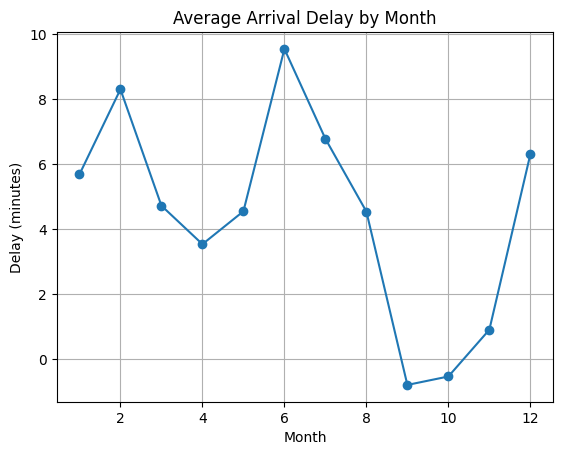

In [55]:
# Average delay per month
monthly_delay = df.groupby("MONTH")["ARRIVAL_DELAY"].mean()

plt.figure()
monthly_delay.plot(kind='line', marker='o')
plt.title("Average Arrival Delay by Month")
plt.xlabel("Month")
plt.ylabel("Delay (minutes)")
plt.grid()
plt.show()

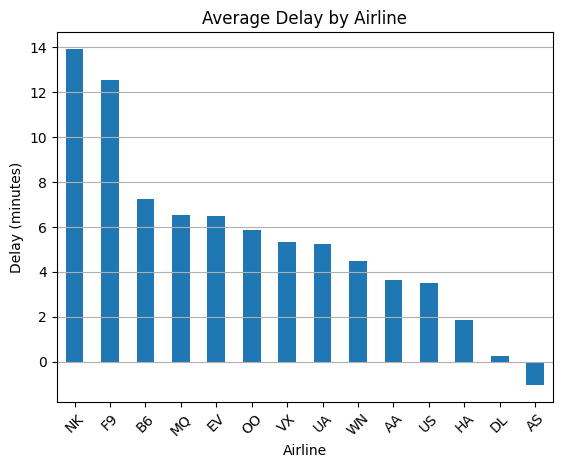

In [56]:
# Delay by airline
airline_delay = df.groupby("AIRLINE")["ARRIVAL_DELAY"].mean().sort_values(ascending=False)

plt.figure()
airline_delay.plot(kind='bar')
plt.title("Average Delay by Airline")
plt.xlabel("Airline")
plt.ylabel("Delay (minutes)")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

## 3. Cancellation Analysis
This section explores the reasons behind flight cancellations. 
It helps understand the main factors affecting flight operations.

In [57]:
# Filter cancelled flights
cancelled_flights = df[df["CANCELLED"] == 1]

# Count reasons
cancellation_counts = cancelled_flights["CANCELLATION_REASON"].value_counts()

# Map codes
reason_map = {
    "A": "Carrier",
    "B": "Weather",
    "C": "NAS",
    "D": "Security"
}

cancellation_counts.index = cancellation_counts.index.map(reason_map)

# Convert to dataframe
cancellation_counts = cancellation_counts.reset_index()
cancellation_counts.columns = ["Reason", "Count"]

# Pie chart
fig = px.pie(
    cancellation_counts,
    names="Reason",
    values="Count",
    title="Flight Cancellation Reasons"
)

fig.show()

## 4. Airport Analysis
This section identifies the busiest airports based on flight volume. 
It highlights major hubs with high traffic.

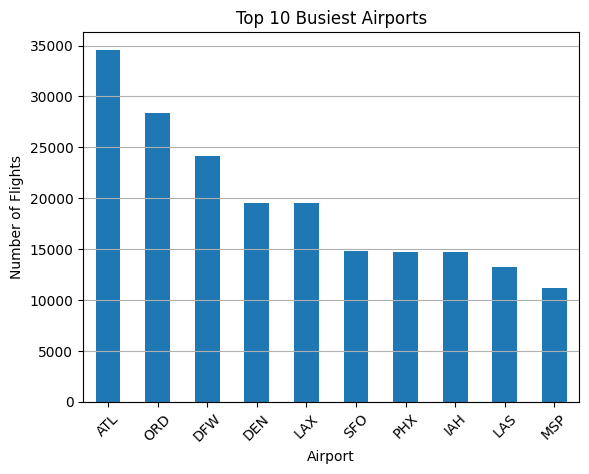

In [58]:
# Top airports
top_airports = df["ORIGIN_AIRPORT"].value_counts().head(10)

plt.figure()
top_airports.plot(kind='bar')
plt.title("Top 10 Busiest Airports")
plt.xlabel("Airport")
plt.ylabel("Number of Flights")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

## 5. Seasonal (Winter) Impact
This section analyzes how winter months affect flight delays and cancellations. 
It compares winter performance with overall trends.

In [59]:
# Winter months
winter_df = df[df["MONTH"].isin([12,1,2])]

# Metrics
winter_delay = winter_df["ARRIVAL_DELAY"].mean()
overall_delay = df["ARRIVAL_DELAY"].mean()

winter_cancel_rate = winter_df["CANCELLED"].mean()
winter_cancel_percent = winter_cancel_rate * 100

print("Winter Avg Delay:", winter_delay)
print("Overall Avg Delay:", overall_delay)
print("Winter Cancellation Rate:", winter_cancel_rate)
print("Winter Cancellation Percentage:", winter_cancel_percent)

Winter Avg Delay: 6.709740167436014
Overall Avg Delay: 4.454959012387057
Winter Cancellation Rate: 0.029993613747859155
Winter Cancellation Percentage: 2.9993613747859156


## Conclusion

The analysis shows that flight delays and cancellations are influenced by multiple factors such as airline operations, weather conditions, and airport traffic.

Winter months experience higher delays and cancellation rates compared to the overall average, indicating the significant impact of seasonal conditions on flight performance.

This study provides useful insights into airline operations and can help improve planning and decision-making.